# Crop Pest DenseNet121 Classifier
Transfer learning from ImageNet-pretrained DenseNet121 on YOLO-cropped pest images

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent))

import os
import time
from tqdm import tqdm

import numpy as np
import torch
import torchvision
from torchvision import transforms, datasets
from torch import nn, optim
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report

from shared import (
    resolve_paths, set_seed, get_device,
    build_classification_dataset, evaluate,
    plot_confusion_matrix, plot_training_curves,
    save_metrics_csv, save_classification_report,
)

PROJECT_ROOT, DATA_ROOT, OUT_ROOT = resolve_paths()

PROJECT_ROOT: f:\github\agro-pest
DATA_ROOT:    f:\github\agro-pest\archive
OUT_ROOT:     f:\github\agro-pest\runs
Data exists:  True


In [2]:
CONFIG = {
    "YOLO_ROOT": DATA_ROOT,
    "OUT_ROOT": OUT_ROOT,

    "CLASS_NAMES": [
        "Ants", "Bees", "Beetles", "Caterpillars", "Earthworms", "Earwigs",
        "Grasshoppers", "Moths", "Slugs", "Snails", "Wasps", "Weevils",
    ],

    "CROP_MARGIN_RATIO": 0.07,
    "MIN_CROP_SIZE": 10,

    "IMG_SIZE": 224,
    "BATCH_SIZE": 32,
    "NUM_WORKERS": 4,
    "EPOCHS": 15,
    "LR": 4e-4,
    "WEIGHT_DECAY": 1e-4,
    "SEED": 42,
    "SAVE_BEST_METRIC": "macro_f1",
    "FREEZE_BACKBONE": False,
}

cfg = CONFIG

In [3]:
def get_dataloaders(ds_root, img_size=224, batch=32, workers=4):
    norm_mean = [0.485, 0.456, 0.406]
    norm_std = [0.229, 0.224, 0.225]

    tf_train = transforms.Compose([
        transforms.RandomResizedCrop(img_size, scale=(0.9, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ColorJitter(0.2, 0.2, 0.2, 0.1),
        transforms.ToTensor(),
        transforms.Normalize(norm_mean, norm_std),
    ])
    tf_eval = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(norm_mean, norm_std),
    ])

    train_ds = datasets.ImageFolder(str(Path(ds_root) / "train"), transform=tf_train)
    valid_ds = datasets.ImageFolder(str(Path(ds_root) / "valid"), transform=tf_eval)
    test_ds = datasets.ImageFolder(str(Path(ds_root) / "test"), transform=tf_eval)

    train_dl = DataLoader(train_ds, batch_size=batch, shuffle=True, num_workers=workers, pin_memory=True)
    valid_dl = DataLoader(valid_ds, batch_size=batch, shuffle=False, num_workers=workers, pin_memory=True)
    test_dl = DataLoader(test_ds, batch_size=batch, shuffle=False, num_workers=workers, pin_memory=True)
    return train_dl, valid_dl, test_dl, train_ds.classes

In [4]:
def create_model(num_classes, freeze_backbone=False):
    model = torchvision.models.densenet121(
        weights=torchvision.models.DenseNet121_Weights.IMAGENET1K_V1
    )
    if freeze_backbone:
        for p in model.features.parameters():
            p.requires_grad = False
    in_features = model.classifier.in_features
    model.classifier = nn.Linear(in_features, num_classes)
    return model

In [5]:
set_seed(cfg["SEED"])
device = get_device()
print(f"[device] {device}")

ds_cls_root = build_classification_dataset(
    yolo_root=cfg["YOLO_ROOT"],
    out_root=cfg["OUT_ROOT"],
    class_names=cfg["CLASS_NAMES"],
    margin_ratio=cfg["CROP_MARGIN_RATIO"],
    min_crop=cfg["MIN_CROP_SIZE"],
)

[device] cuda
[build] train: 11502 images


Build train: 100%|██████████| 11502/11502 [03:13<00:00, 59.33it/s] 


[build] valid: 1095 images


Build valid: 100%|██████████| 1095/1095 [00:30<00:00, 36.17it/s] 


[build] test: 546 images


Build test: 100%|██████████| 546/546 [00:19<00:00, 28.30it/s]

[build] Cropped classification dataset at: f:\github\agro-pest\runs\dataset_cls
  train: 15271 samples
  valid: 1341 samples
  test: 689 samples


In [6]:
train_dl, valid_dl, test_dl, classes = get_dataloaders(
    ds_cls_root, img_size=cfg["IMG_SIZE"], batch=cfg["BATCH_SIZE"], workers=cfg["NUM_WORKERS"]
)
print(f"[data] classes: {classes}")

model = create_model(num_classes=len(cfg["CLASS_NAMES"]), freeze_backbone=cfg["FREEZE_BACKBONE"]).to(device)
params = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.AdamW(params, lr=cfg["LR"], weight_decay=cfg["WEIGHT_DECAY"])
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg["EPOCHS"])
criterion = nn.CrossEntropyLoss()

best_metric = -1.0
save_dir = Path(cfg["OUT_ROOT"]) / f"densenet_run_{time.strftime('%Y%m%d_%H%M%S')}"
save_dir.mkdir(parents=True, exist_ok=True)
best_w_path = save_dir / "best_densenet.pth"

train_losses, valid_accs, valid_f1s = [], [], []

for epoch in range(1, cfg["EPOCHS"] + 1):
    model.train()
    running_loss = 0.0
    t0 = time.perf_counter()
    pbar = tqdm(train_dl, desc=f"Epoch {epoch:02d}/{cfg['EPOCHS']}", leave=False)
    for x, y in pbar:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * x.size(0)
        pbar.set_postfix(loss=f"{loss.item():.4f}")
    scheduler.step()
    train_loss = running_loss / len(train_dl.dataset)

    acc, prec, rec, f1, cm, _, _ = evaluate(model, valid_dl, device, desc="Valid")
    metric = f1 if cfg["SAVE_BEST_METRIC"] == "macro_f1" else acc
    dt = time.perf_counter() - t0
    print(
        f"[epoch {epoch:02d}] {dt:.1f}s | lr={scheduler.get_last_lr()[0]:.2e} "
        f"| train_loss={train_loss:.4f} | valid_acc={acc:.4f} valid_f1={f1:.4f}"
    )

    train_losses.append(train_loss)
    valid_accs.append(acc)
    valid_f1s.append(f1)

    if metric > best_metric:
        best_metric = metric
        torch.save(model.state_dict(), best_w_path)
        print(f"  -> saved best to {best_w_path}")

[data] classes: ['Ants', 'Bees', 'Beetles', 'Caterpillars', 'Earthworms', 'Earwigs', 'Grasshoppers', 'Moths', 'Slugs', 'Snails', 'Wasps', 'Weevils']


[epoch 01] 73.6s | lr=3.96e-04 | train_loss=0.6209 | valid_acc=0.8345 valid_f1=0.8247
  -> saved best to f:\github\agro-pest\runs\densenet_run_20260429_192217\best_densenet.pth


[epoch 02] 66.8s | lr=3.83e-04 | train_loss=0.3409 | valid_acc=0.8412 valid_f1=0.8334
  -> saved best to f:\github\agro-pest\runs\densenet_run_20260429_192217\best_densenet.pth


[epoch 03] 64.3s | lr=3.62e-04 | train_loss=0.2494 | valid_acc=0.8732 valid_f1=0.8654
  -> saved best to f:\github\agro-pest\runs\densenet_run_20260429_192217\best_densenet.pth


[epoch 04] 64.9s | lr=3.34e-04 | train_loss=0.1859 | valid_acc=0.8501 valid_f1=0.8443


...

[epoch 11] 74.1s | lr=6.62e-05 | train_loss=0.0141 | valid_acc=0.8896 valid_f1=0.8827
  -> saved best to f:\github\agro-pest\runs\densenet_run_20260429_192217\best_densenet.pth


[epoch 12] 74.5s | lr=3.82e-05 | train_loss=0.0073 | valid_acc=0.8956 valid_f1=0.8924
  -> saved best to f:\github\agro-pest\runs\densenet_run_20260429_192217\best_densenet.pth


[epoch 13] 74.3s | lr=1.73e-05 | train_loss=0.0052 | valid_acc=0.8978 valid_f1=0.8944
  -> saved best to f:\github\agro-pest\runs\densenet_run_20260429_192217\best_densenet.pth


[epoch 14] 74.1s | lr=4.37e-06 | train_loss=0.0044 | valid_acc=0.8934 valid_f1=0.8895


[epoch 15] 74.2s | lr=0.00e+00 | train_loss=0.0028 | valid_acc=0.8963 valid_f1=0.8930


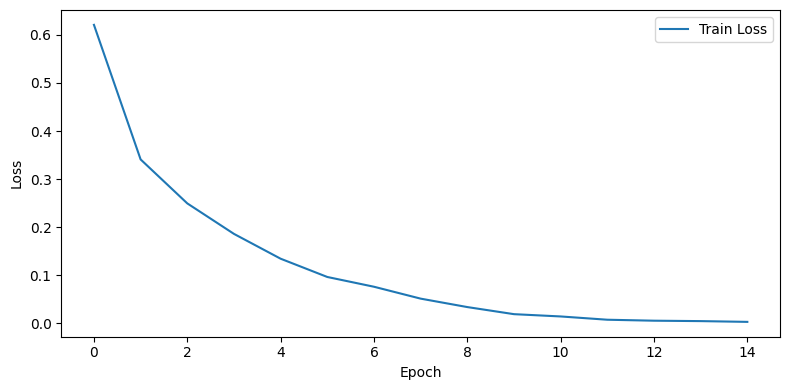

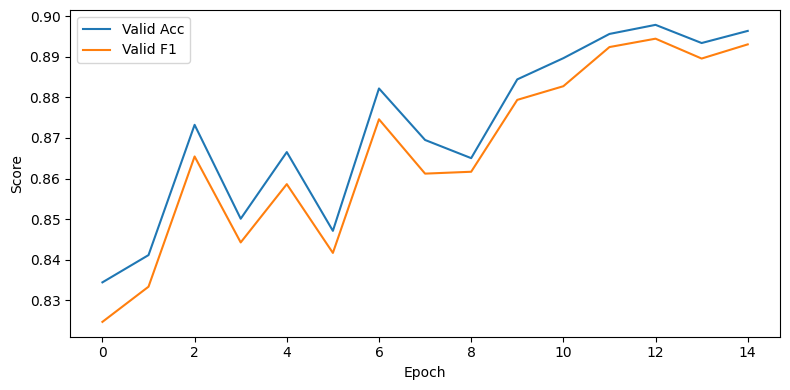

In [7]:
plot_training_curves(train_losses, valid_accs, valid_f1s, save_dir)

Valid: acc=0.8978 prec=0.8969 rec=0.8931 f1=0.8944
Test:  acc=0.8926 prec=0.8976 rec=0.8942 f1=0.8929

Confusion Matrix (Valid):


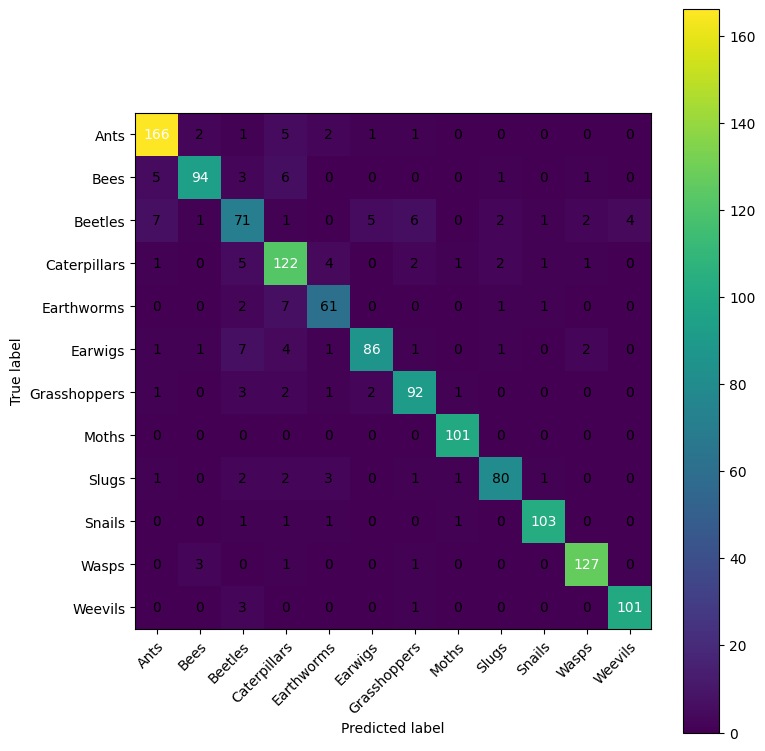


Confusion Matrix (Test):


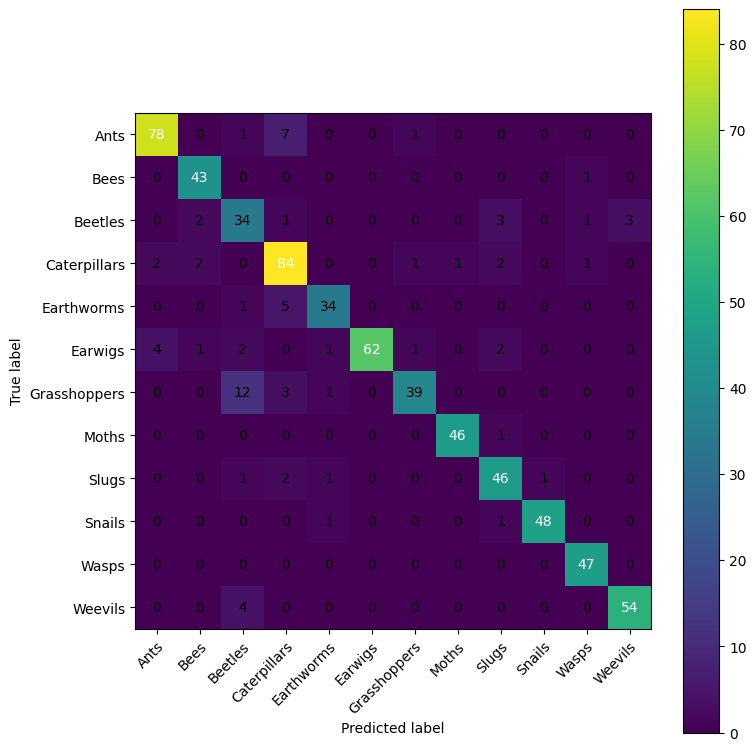


Classification Report (Test):
              precision    recall  f1-score   support

        Ants     0.9286    0.8966    0.9123        87
        Bees     0.8958    0.9773    0.9348        44
     Beetles     0.6182    0.7727    0.6869        44
Caterpillars     0.8235    0.9032    0.8615        93
  Earthworms     0.8947    0.8500    0.8718        40
     Earwigs     1.0000    0.8493    0.9185        73
Grasshoppers     0.9286    0.7091    0.8041        55
       Moths     0.9787    0.9787    0.9787        47
       Slugs     0.8364    0.9020    0.8679        51
      Snails     0.9796    0.9600    0.9697        50
       Wasps     0.9400    1.0000    0.9691        47
     Weevils     0.9474    0.9310    0.9391        58

    accuracy                         0.8926       689
   macro avg     0.8976    0.8942    0.8929       689
weighted avg     0.9007    0.8926    0.8937       689


=== DONE (DenseNet121) ===
Artifacts saved in: f:\github\agro-pest\runs\densenet_run_20260429_192217


In [8]:
model.load_state_dict(torch.load(best_w_path, map_location=device, weights_only=True))

acc_v, prec_v, rec_v, f1_v, cm_v, _, _ = evaluate(model, valid_dl, device, desc="Valid")
acc_t, prec_t, rec_t, f1_t, cm_t, y_true_t, y_pred_t = evaluate(model, test_dl, device, desc="Test")

print(f"Valid: acc={acc_v:.4f} prec={prec_v:.4f} rec={rec_v:.4f} f1={f1_v:.4f}")
print(f"Test:  acc={acc_t:.4f} prec={prec_t:.4f} rec={rec_t:.4f} f1={f1_t:.4f}")

print("\nConfusion Matrix (Valid):")
plot_confusion_matrix(cm_v, classes, save_dir / "cm_valid.png")
print("\nConfusion Matrix (Test):")
plot_confusion_matrix(cm_t, classes, save_dir / "cm_test.png")

print("\nClassification Report (Test):")
print(classification_report(y_true_t, y_pred_t, target_names=classes, digits=4))

metrics_csv = save_metrics_csv(save_dir, acc_v, prec_v, rec_v, f1_v, acc_t, prec_t, rec_t, f1_t)
report_txt = save_classification_report(save_dir, y_true_t, y_pred_t, classes)

print("\n=== DONE (DenseNet121) ===")
print(f"Artifacts saved in: {save_dir}")
print(f"  - Best weights: {best_w_path}")
print(f"  - Valid CM:     {save_dir / 'cm_valid.png'}")
print(f"  - Test  CM:     {save_dir / 'cm_test.png'}")
print(f"  - Metrics :     {metrics_csv}")
print(f"  - Report  :     {report_txt}")